In [1]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load data
df = pd.read_csv("dropout_data.csv")
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
df.head()

Shape: (38, 10)

Missing values:
 State/UT                              0
2019-20 - Primary level (I - V)       0
2019-20 - Upper Primary (VI -VIII)    0
2019-20 - Secondary (IX-X)            0
2020-21 - Primary level (I - V)       1
2020-21 - Upper Primary (VI -VIII)    1
2020-21 - Secondary (IX-X)            1
2021-22 - Primary level (I - V)       1
2021-22 - Upper Primary (VI -VIII)    1
2021-22 - Secondary (IX-X)            1
dtype: int64


,State/UT,2019-20 - Primary level (I - V),2019-20 - Upper Primary (VI -VIII),2019-20 - Secondary (IX-X),2020-21 - Primary level (I - V),2020-21 - Upper Primary (VI -VIII),2020-21 - Secondary (IX-X),2021-22 - Primary level (I - V),2021-22 - Upper Primary (VI -VIII),2021-22 - Secondary (IX-X)
0,Andaman and Nicobar Islands,0.5,0.0,15.7,2.3,0.4,7.0,0.4,1.0,5.0
1,Andhra Pradesh,0.0,0.3,14.8,0.0,0.5,16.7,0.0,1.6,16.3
2,Arunachal Pradesh,6.2,7.5,34.3,8.1,7.1,10.1,9.3,6.7,11.7
3,Assam,4.3,3.4,32.2,3.3,4.9,30.3,6.0,8.8,20.3
4,Bihar,2.3,8.9,21.4,0.0,2.8,17.6,0.0,4.6,20.5


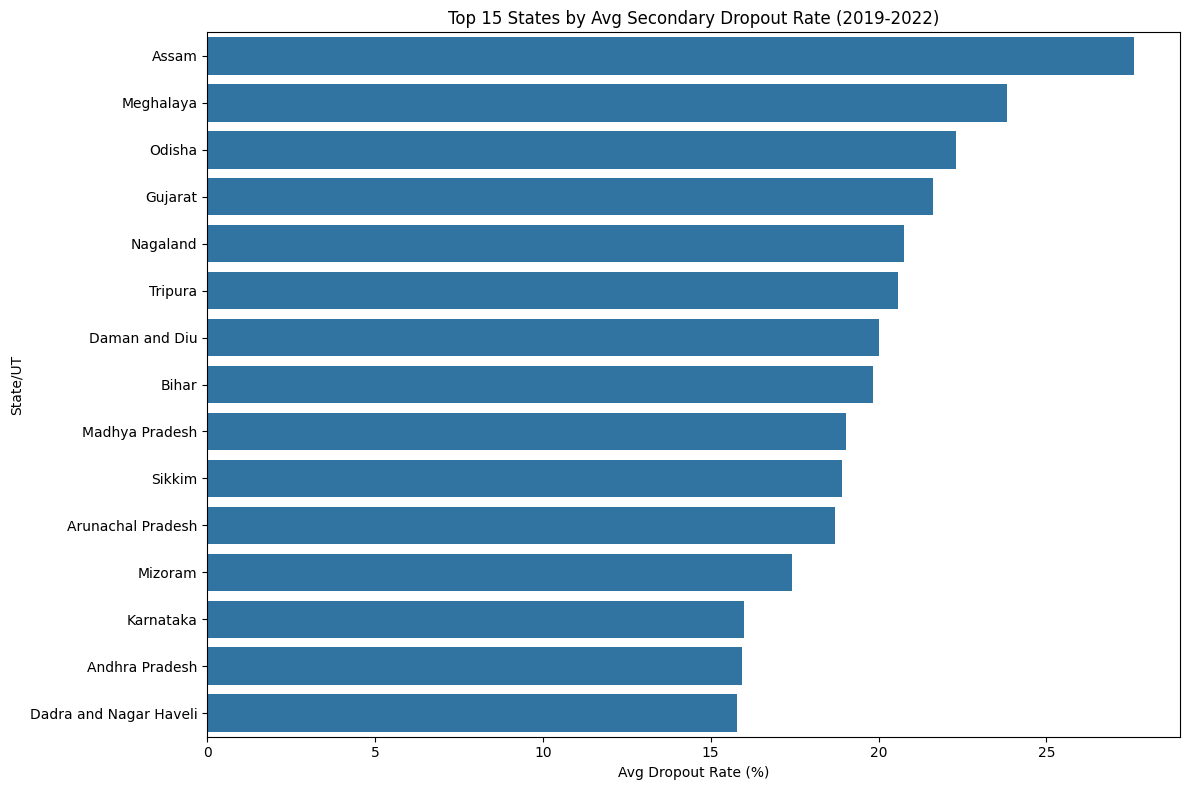

In [3]:
# Which states have highest secondary dropout?

secondary_cols = [c for c in df.columns if "Secondary" in c]
df["avg_secondary_dropout"] = df[secondary_cols].mean(axis=1)
df_sorted = df.sort_values("avg_secondary_dropout", ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=df_sorted.head(15), x="avg_secondary_dropout", y="State/UT")
plt.title("Top 15 States by Avg Secondary Dropout Rate (2019-2022)")
plt.xlabel("Avg Dropout Rate (%)")
plt.tight_layout()
plt.savefig("top_states_dropout.png")
plt.show()


## Observations
- Secondary level has the highest dropout rates across all states
- Dataset needs reshaping to long format for ML — planned for Day 2
- Will merge with literacy/poverty data to add features